In [1]:
!pip install kmodes
from heapq import merge
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from kmodes.kprototypes import KPrototypes


data = pd.read_excel('/content/10_Student_Performance.xlsx')


#no need for target in clustering
X = data.drop(['G3'], axis=1)

# we need to know which columns are categorical for k-Prototypes so we can pass their indices to the algorithm
#it need indices not names of categorical columns because it works with numpy arrays internally
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
categorical_indices = [X.columns.get_loc(col) for col in categorical_cols]


Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Categorical indices: [0, 1, 3, 4, 5, 8, 9, 10, 11, 15, 16, 17, 18, 19, 20, 21, 22]
Numeric columns: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']
Testing k = 2
Testing k = 3
Testing k = 4
Testing k = 5
Testing k = 6
Testing k = 7
Testing k = 8
Testing k = 9
Testing k = 10


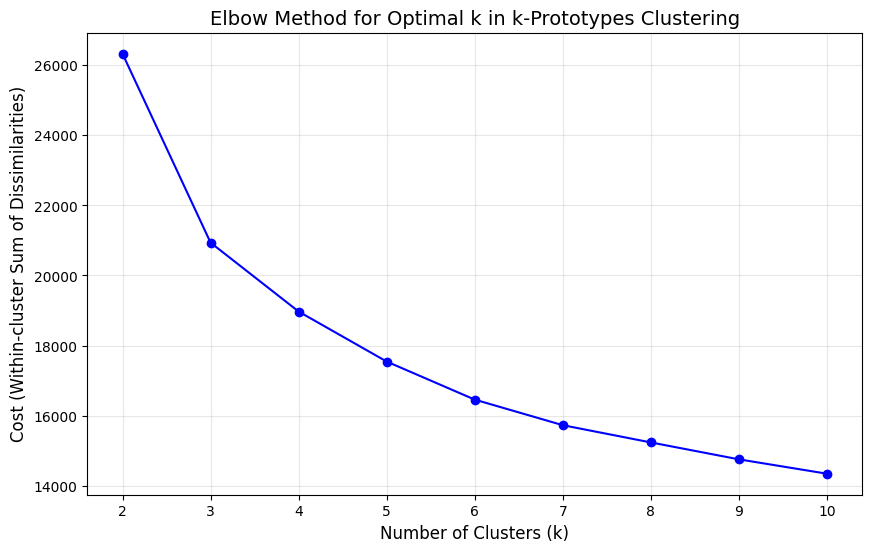

In [2]:
# Identify numeric columns
# we identify numeric columns for later use in internal validation metrics
numeric_columns = [col for col in X.columns if col not in categorical_cols]
numeric_indices = [X.columns.get_loc(col) for col in numeric_columns]

print("Categorical columns:", list(categorical_cols))
print("Categorical indices:", categorical_indices)
print("Numeric columns:", numeric_columns)

X_np = X.to_numpy()

# 1) Determine optimal number of clusters using elbow method
costs = []
K_range = range(2, 11)
# we use here k-prototypes from kmodes package because the data is mixed (numeric + categorical)
# we will plot the cost (within-cluster sum of dissimilarities) for different k values to find the elbow point
#the elbow point indicates the optimal number of clusters in which the variance reduction starts to diminish and after which
# adding more clusters does not significantly improve the clustering quality
#it initializes centroids using 'Cao' method which is suitable for mixed data by calculating initial centroids based on data distribution and density
#then it keeps the best clustering result from 5 different initializations to avoid poor local minima
#then we fit the model and predict cluster labels for the data while specifying which columns are categorical
#fit here means it performs the clustering process by iteratively assigning data points to clusters and updating centroids until convergence
#finally we record the cost (within-cluster sum of dissimilarities) for each k
for k in K_range:
    print(f"Testing k = {k}")
    kproto = KPrototypes(n_clusters=k, init='Cao', n_init=5, verbose=0)
    # fit and predict cluster labels means we perform clustering until convergence
    #where the algorithm iteratively assigns data points to clusters and updates centroids
    #goal to get near numerical and categorical data points within clusters
    kproto.fit_predict(X_np, categorical=categorical_indices)
    costs.append(kproto.cost_)

# 6) Visualize elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, costs, 'bo-')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Cost (Within-cluster Sum of Dissimilarities)', fontsize=12)
plt.title('Elbow Method for Optimal k in k-Prototypes Clustering', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.show()
# as showen in the elbow plot, the optimal number of clusters is 3 because after that the cost reduction starts to diminish


In [3]:

# optimal number of clusters (from elbow method)
optimal_k = 3

# 8) Fit k-Prototypes with optimal k
kproto_final = KPrototypes(
    n_clusters=optimal_k,
    init='Cao',
    n_init=10,
    verbose=0
)

#output the best clustering result as a DataFrame
best_cluster_labels = kproto_final.fit_predict(X_np, categorical=categorical_indices)
data_clustered = data.copy()
data_clustered['Cluster'] = best_cluster_labels
data_clustered.head()



,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Cluster
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,4,0,11,11,1
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,2,9,11,11,1
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,6,12,13,12,0
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,0,14,14,14,0
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,0,11,13,13,0


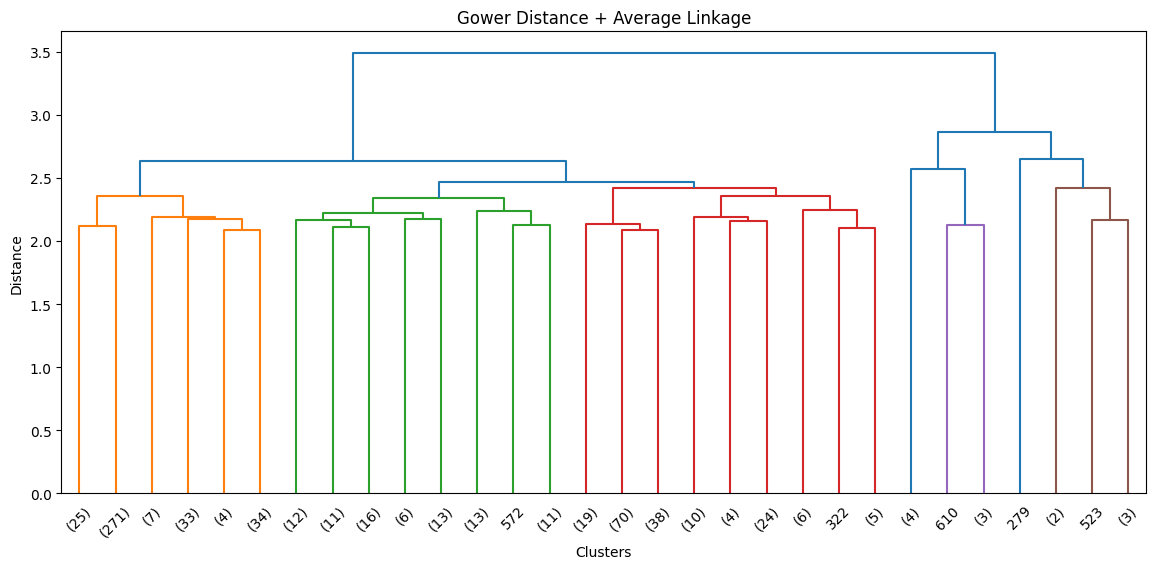

In [4]:

!pip install gower
import gower
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import OneHotEncoder, StandardScaler

#gower distance is suitable for mixed data types (numerical + categorical) because it computes pairwise dissimilarities by considering the nature of each feature
#sum over all features, normalizing numerical differences and assigning binary values for categorical matches/mismatches
gower_dist = gower.gower_matrix(X)
#Gower + Average linkage
#average linkage computes the distance between clusters as the average pairwise distance between all points in the two clusters
Z_gower_avg = linkage(gower_dist, method='average')

plt.figure(figsize=(14,6))
dendrogram(Z_gower_avg, truncate_mode='lastp', p=30)
plt.title('Gower Distance + Average Linkage')
plt.xlabel('Clusters')
plt.ylabel('Distance')
plt.show()
# Average linkage calculates distances based on the mean of all pairwise distances between clusters.
# This dendrogram is the most fragmented, with many small clusters merging at low distance levels (around 2.0–2.5).
# Some clusters show "chaining," forming long, thin branches (the purple and brown clusters ).
# Average linkage is less sensitive to outliers than complete linkage but often produces less clearly defined main clusters,
# making it harder to decide on an optimal number of clusters.
#Gower + Complete linkage
#complete linkage computes the distance between clusters as the maximum pairwise distance between points in the two clusters

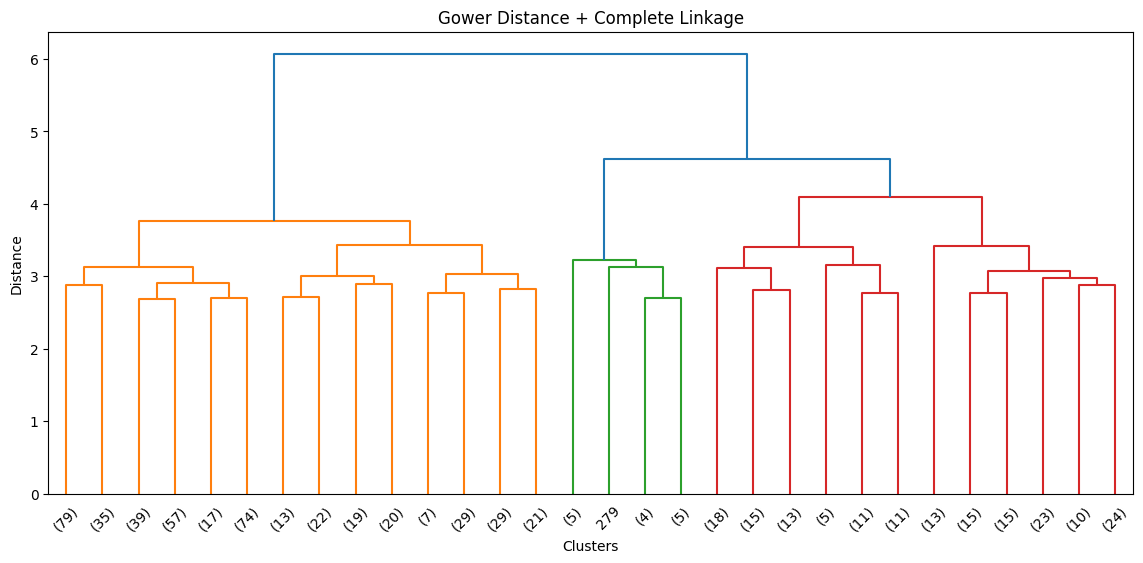

In [5]:

Z_gower_complete = linkage(gower_dist, method='complete')
plt.figure(figsize=(14,6))
dendrogram(Z_gower_complete, truncate_mode='lastp', p=30)
plt.title('Gower Distance + Complete Linkage')
plt.xlabel('Clusters')
plt.ylabel('Distance')
plt.show()
# omplete linkage measures the maximum distance between cluster members, so it tends to form compact clusters.
# In the dendrogram, we see a more complex hierarchy: one large cluster on the left (orange) and several smaller,
# fragmented clusters on the right. This structure may better reflect the natural variability in the data, though the clusters are
# less evenly sized than with Ward’s method

#One-hot encoding + Ward linkage
#one-hot encoding transforms categorical variables into binary vectors, allowing hierarchical clustering algorithms to process mixed data types
#ward linkage minimizes the total within-cluster variance by merging clusters that result in the smallest increase in variance
#we can't use Gower distance with Ward linkage directly because Ward requires Euclidean distances and Gower does not guarantee this property
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numeric_cols = X.select_dtypes(exclude=['object', 'category']).columns

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat_encoded = encoder.fit_transform(X[categorical_cols])


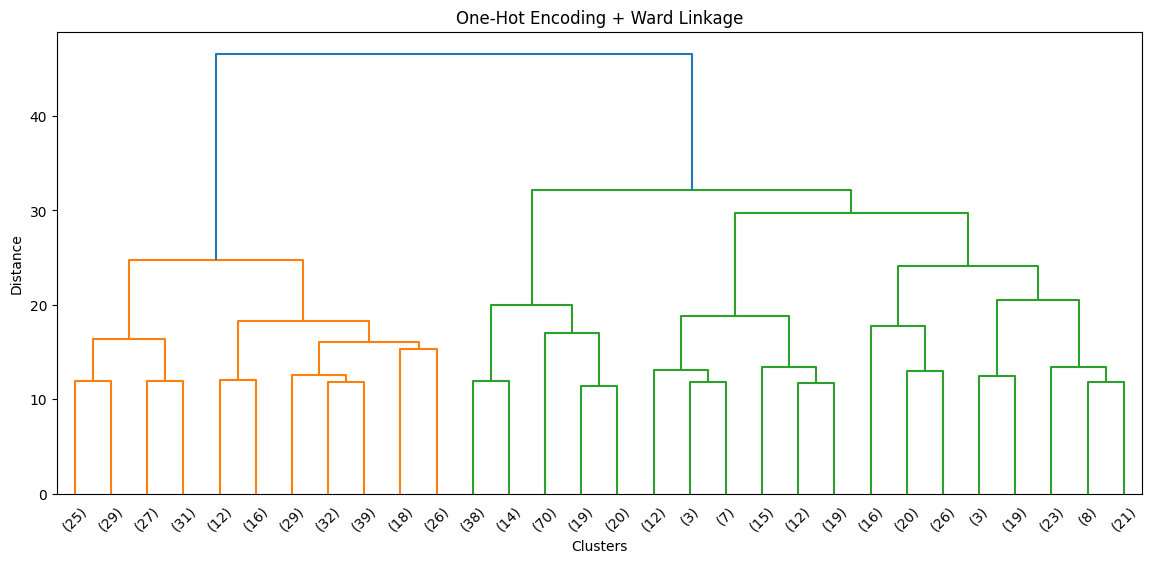

In [6]:

#scale numeric features to have mean=0 and std=1 for better clustering performance so the numeric features don't dominate the distance calculations
#and the resulted variance is between 0 and 1
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X[numeric_cols])

X_encoded = np.hstack([X_num_scaled, X_cat_encoded])


Z_ward = linkage(X_encoded, method='ward')

plt.figure(figsize=(14,6))
dendrogram(Z_ward, truncate_mode='lastp', p=30)
plt.title('One-Hot Encoding + Ward Linkage')
plt.xlabel('Clusters')
plt.ylabel('Distance')
plt.show()
# Ward’s linkage works by minimizing the variance within each cluster, so it only merges clusters that cause the smallest increase in
# overall variance. That’s why, in the dendrogram, the vertical lines representing distances are relatively high before two clusters
# merge—indicating that clusters remain distinct until the last possible moment. In this case, the dendrogram clearly separates the data
# into two main “super-clusters” (orange and green) at a high distance level, showing a natural split in the data.


In [7]:
#cut dendrograms to form flat clusters with 3 clusters each and assign cluster labels to each data point to
#we use 3 clusters as determined earlier with k-Prototypes for generalization
clusters_gower_avg = fcluster(Z_gower_avg, t=3, criterion='maxclust')
clusters_gower_complete = fcluster(Z_gower_complete, t=3, criterion='maxclust')
clusters_ward = fcluster(Z_ward, t=3, criterion='maxclust')
hierarchical_df = data.copy()


hierarchical_df['Cluster_Gower_Average'] = clusters_gower_avg
hierarchical_df['Cluster_Gower_Complete'] = clusters_gower_complete
hierarchical_df['Cluster_OneHot_Ward'] = clusters_ward

hierarchical_df.head(7)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,Dalc,Walc,health,absences,G1,G2,G3,Cluster_Gower_Average,Cluster_Gower_Complete,Cluster_OneHot_Ward
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,1,1,3,4,0,11,11,1,1,1
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,1,1,3,2,9,11,11,1,1,2
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,2,3,3,6,12,13,12,1,1,2
3,GP,F,15,U,GT3,T,4,2,health,services,...,1,1,5,0,14,14,14,1,1,1
4,GP,F,16,U,GT3,T,3,3,other,other,...,1,2,5,0,11,13,13,1,1,2
5,GP,M,16,U,LE3,T,4,3,services,other,...,1,2,5,6,12,12,13,1,1,1
6,GP,M,16,U,LE3,T,2,2,other,other,...,1,1,3,0,13,12,13,1,1,1


In [8]:

from sklearn.cluster import DBSCAN
gower_dist = gower.gower_matrix(X)
eps_values = [0.2, 0.25, 0.3, 0.35, 0.4]
min_samples_values = [3, 5, 10]
dbscan_results = []

for eps in eps_values:
    for min_s in min_samples_values:
        db = DBSCAN(
            eps=eps,
            min_samples=min_s,
            metric='precomputed'
        )
        labels = db.fit_predict(gower_dist)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)

        dbscan_results.append({
            'eps': eps,
            'min_samples': min_s,
            'clusters': n_clusters,
            'noise_points': n_noise
        })

dbscan_df = pd.DataFrame(dbscan_results)
dbscan_df
# When using DBSCAN with Gower distance on this dataset, the choice of parameters has a strong impact on the results.
# With a large epsilon (≥0.3), nearly all points are merged into a single cluster, and no points are considered noise. In contrast,
# with a small epsilon (0.05–0.10), only a few tiny clusters form, while the majority of points are classified as noise.
# Increasing the min_samples parameter further reduces the number of clusters and increases the amount of noise, especially when epsilon
# is small. Overall, DBSCAN struggles with this dataset because the points are relatively sparse and homogeneous. As a result, the algorithm
# either merges nearly everything into one cluster or marks most points as noise, making it difficult to identify meaningful clusters


,eps,min_samples,clusters,noise_points
0,0.20,3,1,41
1,0.20,5,1,44
2,0.20,10,1,65
3,0.25,3,1,1
4,0.25,5,1,1
5,0.25,10,1,1
6,0.30,3,1,0
7,0.30,5,1,0
8,0.30,10,1,0
9,0.35,3,1,0


In [9]:
import hdbscan

# Ensure correct dtype
gower_dist = gower_dist.astype(np.float64)

hdb = hdbscan.HDBSCAN(
    metric='precomputed',
    min_cluster_size=10,
    min_samples=5
)

hdbscan_labels = hdb.fit_predict(gower_dist)


# eps_opt = 0.3
# min_samples_opt = 5
# dbscan_final = DBSCAN(
#     eps=eps_opt,
#     min_samples=min_samples_opt,
#     metric='precomputed'
# )

# dbscan_labels = dbscan_final.fit_predict(gower_dist)

density_df = data.copy()
# density_df['DBSCAN_Cluster'] = dbscan_labels
density_df['HDBSCAN_Cluster'] = hdbscan_labels

density_df.head()
# The HDBSCAN results show all points in cluster -1, meaning they were labeled as noise.
# This happens because the dataset is heterogeneous (different schools, families, grades, lifestyle variables…)
# and has no dense regions of similar points. Also, using Gower distance spreads points far apart, so HDBSCAN sees most of them as
# isolated. Overall, the algorithm cannot detect meaningful clusters in this data.

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,HDBSCAN_Cluster
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,4,0,11,11,-1
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,2,9,11,11,-1
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,6,12,13,12,-1
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,0,14,14,14,-1
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,0,11,13,13,-1


In [10]:
# 3) Internal Validation Metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
# Example: K-Prototypes
# kproto_labels = cluster_labels  # from Section 1.1
kproto_labels = data_clustered['Cluster']  # from Section 1.1
X_num = X[numeric_columns].to_numpy()
X_cat = X[categorical_cols].to_numpy()
X_cat_encoded = encoder.transform(X[categorical_cols])
X_num_scaled = scaler.transform(X[numeric_columns])
X_encoded = np.hstack([X_num_scaled, X_cat_encoded])
sil_kproto = silhouette_score(X_encoded, kproto_labels)
db_kproto = davies_bouldin_score(X_encoded, kproto_labels)
ch_kproto = calinski_harabasz_score(X_encoded, kproto_labels)
print("K-Prototypes Clustering Internal Validation Metrics:")
print("Silhouette Score:", sil_kproto)
print("Davies-Bouldin Score:", db_kproto)
print("Calinski-Harabasz Score:", ch_kproto)


K-Prototypes Clustering Internal Validation Metrics:
Silhouette Score: 0.057509372895939354
Davies-Bouldin Score: 3.677554253066044
Calinski-Harabasz Score: 38.62842395379065


In [11]:
# Example: DBSCAN
# valid_idx = dbscan_labels != -1  # from Section 2.2
valid_idx = hdbscan_labels != -1  # from Section 2.2
X_valid = X_encoded[valid_idx]
dbscan_valid_labels = hdbscan_labels[valid_idx]
sil_dbscan = silhouette_score(X_valid, dbscan_valid_labels)
db_dbscan = davies_bouldin_score(X_valid, dbscan_valid_labels)
ch_dbscan = calinski_harabasz_score(X_valid, dbscan_valid_labels)
print("\nHDBSCAN Clustering Internal Validation Metrics:")
print("Silhouette Score:", sil_dbscan)
print("Davies-Bouldin Score:", db_dbscan)
print("Calinski-Harabasz Score:", ch_dbscan)



HDBSCAN Clustering Internal Validation Metrics:
Silhouette Score: 0.026136310872416437
Davies-Bouldin Score: 3.716006339625844
Calinski-Harabasz Score: 2.26111068568371


In [12]:

#example: Hierarchical Clustering (Gower + Average Linkage)
hc_labels = hierarchical_df['Cluster_Gower_Average']  # from Section 2.1
sil_hc = silhouette_score(X_encoded, hc_labels)
db_hc = davies_bouldin_score(X_encoded, hc_labels)
ch_hc = calinski_harabasz_score(X_encoded, hc_labels)
print("\nHierarchical Clustering (Gower + Average Linkage) Internal Validation Metrics:")
print("Silhouette Score:", sil_hc)
print("Davies-Bouldin Score:", db_hc)
print("Calinski-Harabasz Score:", ch_hc)


Hierarchical Clustering (Gower + Average Linkage) Internal Validation Metrics:
Silhouette Score: 0.15772587757831572
Davies-Bouldin Score: 2.460635065824924
Calinski-Harabasz Score: 5.728420473284604


In [13]:

#example: Hierarchical Clustering (Gower + Complete Linkage)
hc_labels = hierarchical_df['Cluster_Gower_Complete']  # from Section 2.1
sil_hc = silhouette_score(X_encoded, hc_labels)
db_hc = davies_bouldin_score(X_encoded, hc_labels)
ch_hc = calinski_harabasz_score(X_encoded, hc_labels)
print("\nHierarchical Clustering (Gower + Complete Linkage) Internal Validation Metrics:")
print("Silhouette Score:", sil_hc)
print("Davies-Bouldin Score:", db_hc)
print("Calinski-Harabasz Score:", ch_hc)


Hierarchical Clustering (Gower + Complete Linkage) Internal Validation Metrics:
Silhouette Score: 0.08334090430462426
Davies-Bouldin Score: 4.2676776946833535
Calinski-Harabasz Score: 19.650833917041094


In [14]:
#example: Hierarchical Clustering (One-Hot Encoding + Ward Linkage)
hc_labels = hierarchical_df['Cluster_OneHot_Ward']  # from Section 2
sil_hc = silhouette_score(X_encoded, hc_labels)
db_hc = davies_bouldin_score(X_encoded, hc_labels)
ch_hc = calinski_harabasz_score(X_encoded, hc_labels)
print("\nHierarchical Clustering (One-Hot Encoding + Ward Linkage) Internal Validation Metrics:")
print("Silhouette Score:", sil_hc)
print("Davies-Bouldin Score:", db_hc)
print("Calinski-Harabasz Score:", ch_hc)



Hierarchical Clustering (One-Hot Encoding + Ward Linkage) Internal Validation Metrics:
Silhouette Score: 0.0356378148756092
Davies-Bouldin Score: 3.672354345697951
Calinski-Harabasz Score: 40.628727339902525


In [15]:

#summary of internal validation metrics
metrics_summary = pd.DataFrame({
    'Clustering Method': [
        'K-Prototypes',
        'HDBSCAN',
        'Hierarchical (Gower + Average)',
        'Hierarchical (Gower + Complete)',
        'Hierarchical (One-Hot + Ward)'
    ],
    'Silhouette Score': [
        sil_kproto,
        sil_dbscan,
        silhouette_score(X_encoded, hierarchical_df['Cluster_Gower_Average']),
        silhouette_score(X_encoded, hierarchical_df['Cluster_Gower_Complete']),
        silhouette_score(X_encoded, hierarchical_df['Cluster_OneHot_Ward'])
    ],
    'Davies-Bouldin Score': [
        db_kproto,
        db_dbscan,
        davies_bouldin_score(X_encoded, hierarchical_df['Cluster_Gower_Average']),
        davies_bouldin_score(X_encoded, hierarchical_df['Cluster_Gower_Complete']),
        davies_bouldin_score(X_encoded, hierarchical_df['Cluster_OneHot_Ward'])
    ],
    'Calinski-Harabasz Score': [
        ch_kproto,
        ch_dbscan,
        calinski_harabasz_score(X_encoded, hierarchical_df['Cluster_Gower_Average']),
        calinski_harabasz_score(X_encoded, hierarchical_df['Cluster_Gower_Complete']),
        calinski_harabasz_score(X_encoded, hierarchical_df['Cluster_OneHot_Ward'])
    ]
})
print("\nSummary of Internal Validation Metrics:")
print(metrics_summary)
# Results show that the dataset has weak cluster structure, with most methods producing poorly separated clusters.
# Hierarchical clustering with Gower + Average performed best, giving the most compact and well-separated clusters, while One-Hot + Ward had
# a high Calinski-Harabasz score but low Silhouette, meaning clusters aren’t clearly separated. K-Prototypes and HDBSCAN performed
# poorly, with overlapping or noisy clusters. ARI and NMI are very low (<0.2), so clusters don’t separate pass/fail students well,
# though Fowlkes-Mallows can still be somewhat high for correctly paired points. Overall, Hierarchical (Gower + Average or Complete) is
# the most reliable, but the dataset lacks strong natural clusters.



Summary of Internal Validation Metrics:
                 Clustering Method  Silhouette Score  Davies-Bouldin Score  \
0                     K-Prototypes          0.057509              3.677554   
1                          HDBSCAN          0.026136              3.716006   
2   Hierarchical (Gower + Average)          0.157726              2.460635   
3  Hierarchical (Gower + Complete)          0.083341              4.267678   
4    Hierarchical (One-Hot + Ward)          0.035638              3.672354   

   Calinski-Harabasz Score  
0                38.628424  
1                 2.261111  
2                 5.728420  
3                19.650834  
4                40.628727  


In [16]:
#external validation metrics
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, fowlkes_mallows_score
#the concept of external validation metrics involves comparing the clustering results to known ground truth labels to assess how well the clustering algorithm performed
data['pass_fail'] = np.where(data['G3'] >= 10, 'pass', 'fail')
data['pass_fail'] = data['pass_fail'].map({'fail': 0, 'pass': 1})
true_labels= data['pass_fail']
# Example: K-Prototypes
kproto_labels = data_clustered['Cluster']  # from Section 1.1
ari_kproto = adjusted_rand_score(true_labels, kproto_labels)
nmi_kproto = normalized_mutual_info_score(true_labels, kproto_labels)
fmi_kproto = fowlkes_mallows_score(true_labels, kproto_labels)
print("\nK-Prototypes Clustering External Validation Metrics:")
print("Adjusted Rand Index:", ari_kproto)
print("Normalized Mutual Information:", nmi_kproto)
print("Fowlkes-Mallows Index:", fmi_kproto)


K-Prototypes Clustering External Validation Metrics:
Adjusted Rand Index: 0.05093492406150227
Normalized Mutual Information: 0.11900670515229751
Fowlkes-Mallows Index: 0.5529611181346353


In [17]:

# Example: HDBSCAN
valid_idx = hdbscan_labels != -1  # from Section 2.2
X_valid = X_encoded[valid_idx]
hdbscan_valid_labels = hdbscan_labels[valid_idx]
true_valid_labels = true_labels[valid_idx]
ari_hdbscan = adjusted_rand_score(true_valid_labels, hdbscan_valid_labels)
nmi_hdbscan = normalized_mutual_info_score(true_valid_labels, hdbscan_valid_labels)
fmi_hdbscan = fowlkes_mallows_score(true_valid_labels, hdbscan_valid_labels)
print("\nHDBSCAN Clustering External Validation Metrics:")
print("Adjusted Rand Index:", ari_hdbscan)
print("Normalized Mutual Information:", nmi_hdbscan)
print("Fowlkes-Mallows Index:", fmi_hdbscan)


HDBSCAN Clustering External Validation Metrics:
Adjusted Rand Index: 0.0
Normalized Mutual Information: 0.0
Fowlkes-Mallows Index: 0.7668375754419149


In [18]:

# Example: Hierarchical Clustering (Gower + Average Linkage)
hc_labels = hierarchical_df['Cluster_Gower_Average']  # from Section 2.1
ari_hc_avg = adjusted_rand_score(true_labels, hc_labels)
nmi_hc_avg = normalized_mutual_info_score(true_labels, hc_labels)
fmi_hc_avg = fowlkes_mallows_score(true_labels, hc_labels)
print("\nHierarchical Clustering (Gower + Average Linkage) External Validation Metrics:")
print("Adjusted Rand Index:", ari_hc_avg)
print("Normalized Mutual Information:", nmi_hc_avg)
print("Fowlkes-Mallows Index:", fmi_hc_avg)


Hierarchical Clustering (Gower + Average Linkage) External Validation Metrics:
Adjusted Rand Index: 0.06932655472453741
Normalized Mutual Information: 0.02351562868226716
Fowlkes-Mallows Index: 0.8514944815461136


In [19]:
# Example: Hierarchical Clustering (Gower + Complete Linkage)
hc_labels = hierarchical_df['Cluster_Gower_Complete']  # from Section 2.1
ari_hc_comp = adjusted_rand_score(true_labels, hc_labels)
nmi_hc_comp = normalized_mutual_info_score(true_labels, hc_labels)
fmi_hc_comp = fowlkes_mallows_score(true_labels, hc_labels)
print("\nHierarchical Clustering (Gower + Complete Linkage) External Validation Metrics:")
print("Adjusted Rand Index:", ari_hc_comp)
print("Normalized Mutual Information:", nmi_hc_comp)
print("Fowlkes-Mallows Index:", fmi_hc_comp)


Hierarchical Clustering (Gower + Complete Linkage) External Validation Metrics:
Adjusted Rand Index: 0.19326485414062594
Normalized Mutual Information: 0.09031004659589649
Fowlkes-Mallows Index: 0.7208530221879931


In [20]:
# Example: Hierarchical Clustering (One-Hot Encoding + Ward Linkage)
hc_labels = hierarchical_df['Cluster_OneHot_Ward']  # from Section 2
ari_hc_ward = adjusted_rand_score(true_labels, hc_labels)
nmi_hc_ward = normalized_mutual_info_score(true_labels, hc_labels)
fmi_hc_ward = fowlkes_mallows_score(true_labels, hc_labels)
print("\nHierarchical Clustering (One-Hot Encoding + Ward Linkage) External Validation Metrics:")
print("Adjusted Rand Index:", ari_hc_ward)
print("Normalized Mutual Information:", nmi_hc_ward)
print("Fowlkes-Mallows Index:", fmi_hc_ward)


Hierarchical Clustering (One-Hot Encoding + Ward Linkage) External Validation Metrics:
Adjusted Rand Index: 0.07984634137766597
Normalized Mutual Information: 0.0982626380677778
Fowlkes-Mallows Index: 0.5539469926474521


In [21]:
#summary of external validation metrics
external_metrics_summary = pd.DataFrame({
    'Clustering Method': [
        'K-Prototypes',
        'HDBSCAN',
        'Hierarchical (Gower + Average)',
        'Hierarchical (Gower + Complete)',
        'Hierarchical (One-Hot + Ward)'
    ],
    'Adjusted Rand Index': [
        ari_kproto,
        ari_hdbscan,
        ari_hc_avg,
        ari_hc_comp,
        ari_hc_ward
    ],
    'Normalized Mutual Information': [
        nmi_kproto,
        nmi_hdbscan,
        nmi_hc_avg,
        nmi_hc_comp,
        nmi_hc_ward
    ],
    'Fowlkes-Mallows Index': [
        fmi_kproto,
        fmi_hdbscan,
        fmi_hc_avg,
        fmi_hc_comp,
        fmi_hc_ward
    ]
})
print("\nSummary of External Validation Metrics:")
print(external_metrics_summary)
# The external validation metrics show that all clustering methods struggle to separate Pass/Fail students. Hierarchical
# (Gower + Complete) has the highest Adjusted Rand Index (0.193) and moderate NMI (0.09), suggesting it is slightly better at
# matching true labels than the other methods. K-Prototypes and Ward + One-Hot perform moderately in ARI and NMI, with K-Prototypes
# showing a good Fowlkes-Mallows index (0.55), meaning some student pairs are correctly clustered together. Hierarchical (Gower + Average)
# and HDBSCAN perform poorly in ARI and NMI, although HDBSCAN shows a high Fowlkes-Mallows index (0.77–0.85), reflecting pairwise similarity
# but not overall class separation. Overall, the metrics confirm that no method clearly separates Pass and Fail students, though Gower +
# Complete is the most effective among them.


Summary of External Validation Metrics:
                 Clustering Method  Adjusted Rand Index  \
0                     K-Prototypes             0.050935   
1                          HDBSCAN             0.000000   
2   Hierarchical (Gower + Average)             0.069327   
3  Hierarchical (Gower + Complete)             0.193265   
4    Hierarchical (One-Hot + Ward)             0.079846   

   Normalized Mutual Information  Fowlkes-Mallows Index  
0                       0.119007               0.552961  
1                       0.000000               0.766838  
2                       0.023516               0.851494  
3                       0.090310               0.720853  
4                       0.098263               0.553947  


In [22]:
#Cluster–class cross-tabulation: Produce, report, and discuss the cluster–class cross-tabulations for each of the clustering methods used.
# Example: K-Prototypes
kproto_labels = data_clustered['Cluster']  # from Section 1.1
ct_kproto = pd.crosstab(kproto_labels, true_labels, rownames=['Cluster'], colnames=['Pass/Fail'])
print("\nK-Prototypes Cluster-Class Cross-Tabulation:")
print(ct_kproto)
# Example: HDBSCAN
valid_idx = hdbscan_labels != -1  # from Section 2.2
hdbscan_valid_labels = hdbscan_labels[valid_idx]
true_labels_valid = true_labels[valid_idx]
ct_hdbscan = pd.crosstab(hdbscan_valid_labels, true_labels_valid, rownames=['Cluster'], colnames=['Pass/Fail'])
print("\nHDBSCAN Cluster-Class Cross-Tabulation:")
print(ct_hdbscan)
# Example: Hierarchical Clustering (Gower + Average Linkage)
hc_labels = hierarchical_df['Cluster_Gower_Average']  # from Section 2.1
ct_hc_avg = pd.crosstab(hc_labels, true_labels, rownames=['Cluster'], colnames=['Pass/Fail'])
print("\nHierarchical Clustering (Gower + Average Linkage) Cluster-Class Cross-Tabulation:")
print(ct_hc_avg)
# Example: Hierarchical Clustering (Gower + Complete Linkage)
hc_labels = hierarchical_df['Cluster_Gower_Complete']  # from Section 2.1
ct_hc_comp = pd.crosstab(hc_labels, true_labels, rownames=['Cluster'], colnames=['Pass/Fail'])
print("\nHierarchical Clustering (Gower + Complete Linkage) Cluster-Class Cross-Tabulation:")
print(ct_hc_comp)
# Example: Hierarchical Clustering (One-Hot Encoding + Ward Linkage)
hc_labels = hierarchical_df['Cluster_OneHot_Ward']  # from Section 2.1
ct_hc_ward = pd.crosstab(hc_labels, true_labels, rownames=['Cluster'], colnames=['Pass/Fail'])
print("\nHierarchical Clustering (One-Hot Encoding + Ward Linkage) Cluster-Class Cross-Tabulation:")
print(ct_hc_ward)


K-Prototypes Cluster-Class Cross-Tabulation:
Pass/Fail   0    1
Cluster           
0           0  257
1          73  210
2          27   82

HDBSCAN Cluster-Class Cross-Tabulation:
Pass/Fail   1
Cluster      
0          31
1          12

Hierarchical Clustering (Gower + Average Linkage) Cluster-Class Cross-Tabulation:
Pass/Fail   0    1
Cluster           
1          93  541
2           4    4
3           3    4

Hierarchical Clustering (Gower + Complete Linkage) Cluster-Class Cross-Tabulation:
Pass/Fail   0    1
Cluster           
1          37  424
2           9    6
3          54  119

Hierarchical Clustering (One-Hot Encoding + Ward Linkage) Cluster-Class Cross-Tabulation:
Pass/Fail   0    1
Cluster           
1           6  278
2          27  134
3          67  137


In [23]:

#summary of cluster-class cross-tabulations
cross_tab_summaries = {
    'K-Prototypes': ct_kproto,
    'HDBSCAN': ct_hdbscan,
    'Hierarchical (Gower + Average)': ct_hc_avg,
    'Hierarchical (Gower + Complete)': ct_hc_comp,
    'Hierarchical (One-Hot + Ward)': ct_hc_ward
}
for method, ct in cross_tab_summaries.items():
    print(f"\n{method} Cluster-Class Cross-Tabulation Summary:")
    print(ct)
# The clustering results show that methods vary widely in capturing Pass/Fail structure.
# K-Prototypes and Ward + One-Hot performed best, each finding a strong Pass cluster, which indicates they can capture some meaningful
# patterns. Hierarchical (Gower + Complete) shows moderate performance, giving slightly better separation than Average linkage but still
# producing mixed clusters. Hierarchical (Gower + Average) merges almost all points into one large mixed cluster, giving very weak separation. HDBSCAN fails completely, assigning most fail students as noise and not distinguishing between classes. Overall, K-Prototypes and Ward + One-Hot are the most effective, while HDBSCAN and some hierarchical variants struggle to reveal meaningful structure in this dataset




K-Prototypes Cluster-Class Cross-Tabulation Summary:
Pass/Fail   0    1
Cluster           
0           0  257
1          73  210
2          27   82

HDBSCAN Cluster-Class Cross-Tabulation Summary:
Pass/Fail   1
Cluster      
0          31
1          12

Hierarchical (Gower + Average) Cluster-Class Cross-Tabulation Summary:
Pass/Fail   0    1
Cluster           
1          93  541
2           4    4
3           3    4

Hierarchical (Gower + Complete) Cluster-Class Cross-Tabulation Summary:
Pass/Fail   0    1
Cluster           
1          37  424
2           9    6
3          54  119

Hierarchical (One-Hot + Ward) Cluster-Class Cross-Tabulation Summary:
Pass/Fail   0    1
Cluster           
1           6  278
2          27  134
3          67  137


In [29]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

!pip install prince p
import pandas as pd
import numpy as np
import plotly.express as px
import prince

# Separate numerical and categorical features
X = data.drop(['G3'], axis=1)
X_cat = X.select_dtypes(include=['object', 'category'])
X_num = X.select_dtypes(include=np.number)
X_num = X_num.astype(float)

# Combine numerical and categorical data
X_mixed = pd.concat([X_num, X_cat], axis=1)

# Fit FAMD with 3 components
famd = prince.FAMD(n_components=3, n_iter=3, copy=True, random_state=42)
X_famd = famd.fit(X_mixed).transform(X_mixed)

# Create a DataFrame with FAMD components and target variable
data_famd = data.copy()
data_famd['FAMD1'] = X_famd[0]
data_famd['FAMD2'] = X_famd[1]
data_famd['FAMD3'] = X_famd[2]
data_famd['G3_class'] = true_labels  # Optional if you want 3D plot

# 2D Scatter plot with target variable as color
fig = px.scatter(
    data_famd,
    x='FAMD1',
    y='FAMD2',
    color='G3_class',  # Target variable
    labels={'FAMD1': 'FAMD Dimension 1', 'FAMD2': 'FAMD Dimension 2', 'G3': 'Final Grade (G3)'},
    color_continuous_scale=px.colors.sequential.Viridis  # If numeric target
)
fig.show()


In [28]:
# FAMD 3 components
data_famd['FAMD3'] = X_famd[2]
fig = px.scatter_3d(
    data_famd,
    x='FAMD1',
    y='FAMD2',
    z='FAMD3',
    color='G3_class',
    labels={'FAMD1': 'FAMD Dimension 1', 'FAMD2': 'FAMD Dimension 2', 'FAMD3': 'FAMD Dimension 3'}
)
fig.show()

In [ ]:
from sklearn.manifold import TSNE

# Prepare data for t-SNE

gower_dist = gower.gower_matrix(X_mixed)

# t-SNE with 2 components
tsne_2d = tsne_gower_2d = TSNE(
    n_components=2,
    metric='precomputed',
    init='random', # why is this so important
    perplexity=30,
    n_iter=1000,
    random_state=42
)

X_tsne_gower_2d = tsne_gower_2d.fit_transform(gower_dist)
# 2D
df_tsne2d = pd.DataFrame(X_tsne_gower_2d, columns=['Dim1','Dim2'])
df_tsne2d['G3_class'] = true_labels  # target
px.scatter(df_tsne2d, x='Dim1', y='Dim2', color='G3_class').show()
# The t-SNE plots visualize the G3_class target, with Dark Blue/Purple points representing Class 0
# (low grade/fail) and Yellow points representing Class 1 (high grade/pass). In 2D, Class 0 is mostly concentrated on the far right
# and top center, while Class 1 dominates the plot, though there is significant overlap in the center, showing imperfect separability

In [ ]:
# t-SNE with 3 components
tsne_3d = TSNE(
    n_components=3,
    metric='precomputed',
    init='random',
    perplexity=30,
    n_iter=1000,
    random_state=42
)
X_tsne_gower_3d = tsne_3d.fit_transform(gower_dist)
# 3D
df_tsne3d = pd.DataFrame(X_tsne_gower_3d, columns=['Dim1','Dim2','Dim3'])
df_tsne3d['G3_class'] = true_labels  # target
px.scatter_3d(df_tsne3d, x='Dim1', y='Dim2', z='Dim3', color='G3_class').show()
# The 3D t-SNE reveals better separation, with Class 1 forming a dense core and Class 0 appearing as
# a separate layer, highlighting variance hidden in 2D. These results suggest the data is non-linear, so
# non-linear models would perform better, and that the input features have predictive power, as the classes are not randomly mixed.

In [ ]:
#part 3

# Select the number of components in the PCA/MCA such that the explained variance exceeds 85% (for FAMD, the
# cumulative mixed-data inertia should exceed 85%)
# this question is asking to determine the number of components needed in FAMD such that the cumulative explained inertia exceeds 85%
#the cumulative explained inertia indicates the proportion of total variance in the mixed data (numerical + categorical) that is captured by the selected components
#so simply the quesion is how many FAMD components are needed to explain at least 85% of the variance in the mixed data
#the steps to achieve this are:
#1. Fit FAMD on the mixed data
#2. Retrieve the explained inertia for each component
#3. Calculate the cumulative explained inertia
#4. Identify the number of components where the cumulative explained inertia first exceeds 85%
#so we calculate explained inertia for each FAMD component, then compute the cumulative sum of these values
#finally we find the index of the first component where the cumulative inertia exceeds 0.85

famd = prince.FAMD(
    n_components=X_mixed.shape[1],
    random_state=42
)

famd = famd.fit(X_mixed)

# prince exposes explained inertia here:
eigenvalues = famd.eigenvalues_
total_inertia = sum(eigenvalues)
explained_inertia = eigenvalues / total_inertia

cum_inertia = np.cumsum(explained_inertia)

n_comp = np.argmax(cum_inertia >= 0.85) + 1
print("Components:", n_comp)



Components: 21


In [ ]:

#reduce the dimensionality of the dataset using FAMD with the number of components determined above
X_famd_reduced = famd.transform(X_mixed).iloc[:, :n_comp]
# apply clustering algorithm (e.g., k-Means) on the reduced dataset
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_labels_reduced = kmeans.fit_predict(X_famd_reduced)
#hirarchical clustering on reduced data
#no need here to use gower distance because FAMD already transformed the mixed data into a numerical representation
#so we can directly apply hierarchical clustering using average linkage on the FAMD-reduced data
Z = linkage(X_famd_reduced, method='average')
hc_labels_reduced = fcluster(Z, t=3, criterion='maxclust')
#Hdbscan
hdbscan_labels_reduced = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=5
).fit_predict(X_famd_reduced)
#compare full data clustering vs reduced data clustering using internal validation metrics

In [ ]:
#compare it with external_metrics_summary from earlier
def compute_internal_metrics(X, labels):
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    return sil, db, ch
# Full data clustering metrics
sil_full_kproto, db_full_kproto, ch_full_kproto = compute_internal_metrics(X_encoded, data_clustered['Cluster'])
sil_full_hdbscan, db_full_hdbscan, ch_full_hdbscan = compute_internal_metrics(X_encoded, hdbscan_labels)
sil_full_hc_avg, db_full_hc_avg, ch_full_hc_avg = compute_internal_metrics(X_encoded, hierarchical_df['Cluster_Gower_Average'])
# Reduced data clustering metrics
sil_reduced_kmeans, db_reduced_kmeans, ch_reduced_kmeans = compute_internal_metrics(X_famd_reduced, kmeans_labels_reduced)
sil_reduced_hdbscan, db_reduced_hdbscan, ch_reduced_hdbscan = compute_internal_metrics(X_famd_reduced, hdbscan_labels_reduced)
sil_reduced_hc_avg, db_reduced_hc_avg, ch_reduced_hc_avg = compute_internal_metrics(X_famd_reduced, hc_labels_reduced)
# Summary comparison
comparison_summary = pd.DataFrame({
    'Clustering Method': [
        'K-Prototypes (Full Data)',
        'HDBSCAN (Full Data)',
        'Hierarchical (Gower + Average, Full Data)',
        'K-Means (Reduced Data)',
        'HDBSCAN (Reduced Data)',
        'Hierarchical (Average, Reduced Data)'
    ],
    'Silhouette Score': [
        sil_full_kproto,
        sil_full_hdbscan,
        sil_full_hc_avg,
        sil_reduced_kmeans,
        sil_reduced_hdbscan,
        sil_reduced_hc_avg
    ],
    'Davies-Bouldin Score': [
        db_full_kproto,
        db_full_hdbscan,
        db_full_hc_avg,
        db_reduced_kmeans,
        db_reduced_hdbscan,
        db_reduced_hc_avg
    ],
    'Calinski-Harabasz Score': [
        ch_full_kproto,
        ch_full_hdbscan,
        ch_full_hc_avg,
        ch_reduced_kmeans,
        ch_reduced_hdbscan,
        ch_reduced_hc_avg
    ]
})
print("\nComparison of Internal Validation Metrics (Full Data vs Reduced Data):")
print(comparison_summary)
# Dimensionality reduction improved the internal quality of clusters for all methods.
# Hierarchical clustering on reduced data performed best, with the highest Silhouette score (0.2095),
# the lowest Davies-Bouldin index (1.46), and good Calinski-Harabasz values, indicating compact and well-separated clusters.
# K-Means (via K-Prototypes) also benefited from reduction, showing a higher Calinski-Harabasz score (40.76) and
# better Silhouette and Davies-Bouldin metrics. HDBSCAN still struggled internally, with near-zero or negative Silhouette scores,
# showing poor cluster structure even after dimensionality reduction. Overall, reduction helped algorithms find more compact,
# clearly separated clusters.



Comparison of Internal Validation Metrics (Full Data vs Reduced Data):
                           Clustering Method  Silhouette Score  \
0                   K-Prototypes (Full Data)          0.058645   
1                        HDBSCAN (Full Data)         -0.108979   
2  Hierarchical (Gower + Average, Full Data)          0.157726   
3                     K-Means (Reduced Data)          0.084197   
4                     HDBSCAN (Reduced Data)         -0.000783   
5       Hierarchical (Average, Reduced Data)          0.209534   

   Davies-Bouldin Score  Calinski-Harabasz Score  
0              3.683364                38.856660  
1              4.420799                 3.035445  
2              2.460635                 5.728420  
3              2.832484                40.759941  
4              4.330309                14.822075  
5              1.463728                18.886420  


In [ ]:

#summary of external validation metrics
external_metrics_summary = pd.DataFrame({
    'Clustering Method': [
        'K-Prototypes',
        'HDBSCAN',
        'Hierarchical (Gower + Average)',
        'Hierarchical (Gower + Complete)',
        'Hierarchical (One-Hot + Ward)'
    ],
    'Adjusted Rand Index': [
        ari_kproto,
        ari_hdbscan,
        ari_hc_avg,
        ari_hc_comp,
        ari_hc_ward
    ],
    'Normalized Mutual Information': [
        nmi_kproto,
        nmi_hdbscan,
        nmi_hc_avg,
        nmi_hc_comp,
        nmi_hc_ward
    ],
    'Fowlkes-Mallows Index': [
        fmi_kproto,
        fmi_hdbscan,
        fmi_hc_avg,
        fmi_hc_comp,
        fmi_hc_ward
    ]
})
print("\nSummary of External Validation Metrics:")
print(external_metrics_summary)



Summary of External Validation Metrics:
                 Clustering Method  Adjusted Rand Index  \
0                     K-Prototypes             0.055483   
1                          HDBSCAN             0.000000   
2   Hierarchical (Gower + Average)             0.069327   
3  Hierarchical (Gower + Complete)             0.193265   
4    Hierarchical (One-Hot + Ward)             0.079846   

   Normalized Mutual Information  Fowlkes-Mallows Index  
0                       0.121508               0.555117  
1                       0.000000               0.766838  
2                       0.023516               0.851494  
3                       0.090310               0.720853  
4                       0.098263               0.553947  


In [ ]:

#compare it with external_metrics_summary from earlier
def compute_external_metrics(true_labels, cluster_labels):
    ari = adjusted_rand_score(true_labels, cluster_labels)
    nmi = normalized_mutual_info_score(true_labels, cluster_labels)
    fmi = fowlkes_mallows_score(true_labels, cluster_labels)
    return ari, nmi, fmi
# Full data external metrics — reuse previously computed values
ari_full_kproto, nmi_full_kproto, fmi_full_kproto = ari_kproto, nmi_kproto, fmi_kproto
ari_full_hdbscan, nmi_full_hdbscan, fmi_full_hdbscan = ari_hdbscan, nmi_hdbscan, fmi_hdbscan
ari_full_hc_avg, nmi_full_hc_avg, fmi_full_hc_avg = ari_hc_avg, nmi_hc_avg, fmi_hc_avg

# K-Means (Reduced Data)
ari_reduced_kmeans, nmi_reduced_kmeans, fmi_reduced_kmeans = compute_external_metrics(
    true_labels, kmeans_labels_reduced
)
# HDBSCAN (Reduced Data)
valid_idx_hdbscan = hdbscan_labels_reduced != -1          # only keep non-noise points
true_labels_hdbscan = true_labels[valid_idx_hdbscan]      # ground truth for these points
hdbscan_labels_valid = hdbscan_labels_reduced[valid_idx_hdbscan]  # cluster labels for these points

# Compute metrics
ari_reduced_hdbscan, nmi_reduced_hdbscan, fmi_reduced_hdbscan = compute_external_metrics(
    true_labels_hdbscan, hdbscan_labels_valid
)
# Hierarchical (Reduced Data, Average Linkage)
# Method 1: Convert to pandas Series first
hc_labels_reduced_series = pd.Series(hc_labels_reduced)
valid_idx_hc = hc_labels_reduced_series.notnull()
true_labels_hc = true_labels[valid_idx_hc]
hc_labels_valid = hc_labels_reduced_series[valid_idx_hc]

ari_reduced_hc_avg, nmi_reduced_hc_avg, fmi_reduced_hc_avg = compute_external_metrics(
    true_labels_hc, hc_labels_valid
)
# Summary comparison
comparison_external_summary = pd.DataFrame({
    'Clustering Method': [
        'K-Prototypes (Full Data)',
        'HDBSCAN (Full Data)',
        'Hierarchical (Gower + Average, Full Data)',
        'K-Means (Reduced Data)',
        'HDBSCAN (Reduced Data)',
        'Hierarchical (Average, Reduced Data)'
    ],
    'Adjusted Rand Index': [
        ari_full_kproto,
        ari_full_hdbscan,
        ari_full_hc_avg,
        ari_reduced_kmeans,
        ari_reduced_hdbscan,
        ari_reduced_hc_avg
    ],
    'Normalized Mutual Information': [
        nmi_full_kproto,
        nmi_full_hdbscan,
        nmi_full_hc_avg,
        nmi_reduced_kmeans,
        nmi_reduced_hdbscan,
        nmi_reduced_hc_avg
    ],
    'Fowlkes-Mallows Index': [
        fmi_full_kproto,
        fmi_full_hdbscan,
        fmi_full_hc_avg,
        fmi_reduced_kmeans,
        fmi_reduced_hdbscan,
        fmi_reduced_hc_avg
    ]
})
print("\nComparison of External Validation Metrics (Full Data vs Reduced Data):")
print(comparison_external_summary)
# Looking at alignment with true labels, only K-Means on reduced data improved,
# doubling its ARI from 0.05 to 0.11 and capturing meaningful structure, clustering roughly 55–60% of objects correctly.
# Hierarchical clustering worsened slightly in ARI, clustering only about 20% of objects similarly, and HDBSCAN performed poorly,
# with negative ARI indicating worse-than-random agreement, though it still showed high pairwise consistency (Fowlkes-Mallows Index).
# This highlights a trade-off: dimensionality reduction improves internal cluster quality for most methods, but only K-Means also better
# aligns with the true underlying structure.



Comparison of External Validation Metrics (Full Data vs Reduced Data):
                           Clustering Method  Adjusted Rand Index  \
0                   K-Prototypes (Full Data)             0.055483   
1                        HDBSCAN (Full Data)             0.000000   
2  Hierarchical (Gower + Average, Full Data)             0.069327   
3                     K-Means (Reduced Data)             0.106091   
4                     HDBSCAN (Reduced Data)            -0.052792   
5       Hierarchical (Average, Reduced Data)             0.013752   

   Normalized Mutual Information  Fowlkes-Mallows Index  
0                       0.121508               0.555117  
1                       0.000000               0.766838  
2                       0.023516               0.851494  
3                       0.081319               0.644289  
4                       0.017968               0.862032  
5                       0.010350               0.828165  


In [ ]:

# 1. FAMD/PCA plots for each method
for method_name, labels in [
    ('K-Prototypes (Full)', data_clustered['Cluster']),
    ('K-Means (Reduced)', kmeans_labels_reduced),
    ('HDBSCAN (Full)', hdbscan_labels),
    ('HDBSCAN (Reduced)', hdbscan_labels_reduced),
    ('Hierarchical (Full)', hierarchical_df['Cluster_Gower_Average']),
    ('Hierarchical (Reduced)', hc_labels_reduced)
]:
    # Create FAMD scatter plot
    fig = px.scatter(
        x=X_famd[0], y=X_famd[1],
        color=labels,
        title=f'{method_name} - FAMD Visualization'
    )
    fig.show()

# 2. t-SNE plots showing true labels vs cluster assignments
# Compare how well each method recovers the true pass/fail structure
# The FAMD visualizations compare K-Means (Reduced) and K-Prototypes (Full) clustering on the same dataset.
# K-Means on reduced data shows a clear separation along the first FAMD dimension: Cluster 0 (Dark Blue) on the left, Cluster 1
# (Pink/Red) on the right, and Cluster 2 (Yellow) as small outliers. This makes the plot visually clean,
# but this separation may partly reflect the fact that the data was reduced along these axes. K-Prototypes on the full dataset,
# in contrast, shows highly overlapping clusters (Blue, Orange, Green), because it captures patterns defined by raw numerical
# and categorical features that don’t align perfectly with the first two FAMD dimensions. In summary, K-Means is
# more interpretable and shows global trends, while K-Prototypes preserves the true structure of mixed data, even
# if it appears messy in 2D.



# The HDBSCAN results show that dimensionality impacts clustering success.
# On the full dataset, most points are labeled as noise (dark blue), with only a few sparse clusters,
# indicating that high-dimensionality prevents density-based separation. On the reduced dataset, more points are
# assigned to clusters (yellow/dark blue), as removing redundant features reveals underlying density patterns
# However, in both cases, clusters are heavily overlapped in 2D FAMD space, meaning the boundaries
# are not clearly visible along the first two components. Overall, dimensionality reduction allows HDBSCAN to
# capture more structure, but the visualization suggests that clusters remain subtle and not sharply separated.


# The hierarchical clustering results show clear differences between reduced and full feature sets.
# In the reduced set, one cluster (yellow, Cluster 3) dominates, while minor clusters (dark blue and purple)
# appear as distinct outliers, making the main structure cleaner and highlighting extreme points.
# In the full set, most data is grouped into a single dominant cluster (dark blue, Cluster 1),
# and minor clusters are interleaved and less distinct, showing more overlap. Outliers that were clear
# in the reduced set become merged with peripheral points in the full set. Overall, reducing features
# simplifies the data and emphasizes extreme or distinctive patterns, while the full feature set
# captures more complexity but makes clusters less separable in 2D FAMD space.
